In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.plotting import (analyze_attention_ROI, barplot_morey,
                                plot_decoding_nvoxels)

In [18]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. Visual modality: t(23)=3.8526, p=0.0004. Auditory modality: t(23)=1.7065, p=0.0945
24 subjects in 100 voxels mask. Visual modality: t(23)=4.9108, p=0.0000. Auditory modality: t(23)=4.3278, p=0.0001
23 subjects in 150 voxels mask. Visual modality: t(22)=6.4608, p=0.0000. Auditory modality: t(22)=3.9624, p=0.0003
23 subjects in 200 voxels mask. Visual modality: t(22)=6.2898, p=0.0000. Auditory modality: t(22)=5.0205, p=0.0000
23 subjects in 250 voxels mask. Visual modality: t(22)=6.9007, p=0.0000. Auditory modality: t(22)=5.5404, p=0.0000
23 subjects in 300 voxels mask. Visual modality: t(22)=7.8709, p=0.0000. Auditory modality: t(22)=5.3253, p=0.0000
23 subjects in 350 voxels mask. Visual modality: t(22)=8.0259, p=0.0000. Auditory modality: t(22)=4.5688, p=0.0000
24 subjects in funcloc voxels mask. Visual modality: t(23)=6.4012, p=0.0000. Auditory modality: t(23)=5.3528, p=0.0000
25 subjects in wholeROI voxels mask. Visual modality: t(24)=5.7604, p=0.0000.

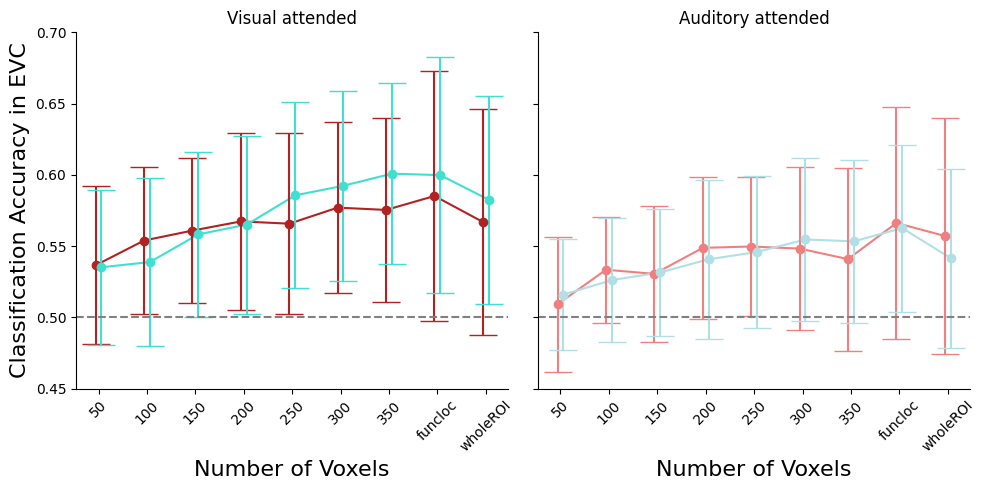

In [ ]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred", save_fig=False)

## Analyze specific ROIs

In [19]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

In [26]:
df

,subj,run,labels,svc_predictions,svc_probabilities,decision_distances,pred,ign_pred,att_learned,ign_learned,...,expected_stim,bilateralHC,subiculum,CA1,CA3,GC_DG,CA3DG,bilateralV1,bilateralV2,bilateralA1
0,sub-02,MAIN1,45,45,[0.41846609 0.58153391],0.115478,1,1,1,1,...,0,-0.441566,-2.046490,0.562821,0.038550,-2.113545,-1.496055,-0.972470,-1.675203,-2.013246
1,sub-02,MAIN1,45,135,[0.58753108 0.41246892],-0.138802,1,1,1,0,...,0,1.095644,0.042813,0.973710,-0.286903,-0.104360,-0.134957,1.282393,0.709603,-1.099023
2,sub-02,MAIN1,45,45,[0.15475948 0.84524052],0.625480,1,1,1,1,...,0,-0.971337,0.475205,-1.018587,-0.869581,0.897005,-0.278367,-0.477074,-0.567263,0.030824
3,sub-02,MAIN1,45,45,[0.41415228 0.58584772],0.121954,1,1,1,1,...,0,1.806306,1.125564,1.015515,0.172603,0.658123,0.540742,0.344802,-0.032082,0.016895
4,sub-02,MAIN1,135,135,[0.91729471 0.08270529],-0.902578,1,1,1,0,...,1,0.508089,0.389158,0.612623,0.075983,-0.071764,0.221755,0.659193,0.024197,0.719681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479995,sub-27,MAIN6,45,135,[0.50780698 0.49219302],-0.232728,0,0,0,0,...,1,1.880622,1.980534,1.780532,1.317407,1.964140,1.747214,2.247477,2.400494,2.129336
479996,sub-27,MAIN6,135,45,[0.48133842 0.51866158],0.345872,0,0,0,1,...,0,-1.217775,-0.802694,-1.069397,-1.142142,-1.040608,-1.129348,-0.972745,-1.397908,-0.977248
479997,sub-27,MAIN6,135,45,[0.48517853 0.51482147],0.261873,0,1,0,0,...,1,0.355181,0.684815,0.324374,-0.113500,0.076596,-0.008635,0.117335,0.142987,-0.008991
479998,sub-27,MAIN6,45,45,[0.5 0.5],0.030355,0,1,1,1,...,0,-0.294521,-0.691668,-0.102427,0.125607,-0.191474,-0.064888,-0.999970,-0.863125,-0.754494


In [ ]:
df["prob_predictions"] = np.where(df["prob_0"] < 0.5, )

labels
45     0.480260
135    0.517861
Name: prob_0, dtype: float64

In [25]:
df.columns

Index(['subj', 'run', 'labels', 'svc_predictions', 'svc_probabilities',
       'decision_distances', 'pred', 'ign_pred', 'att_learned', 'ign_learned',
       'modality', 'perm', 'trial', 'n_voxels', 'prob_0', 'prob_1',
       'z_distance', 'correct', 'v_pred', 'a_pred', 'v_learned', 'a_learned',
       'stim', 'classified_stim', 'expected_stim', 'bilateralHC', 'subiculum',
       'CA1', 'CA3', 'GC_DG', 'CA3DG', 'bilateralV1', 'bilateralV2',
       'bilateralA1'],
      dtype='object')

### Attention * visual prediction

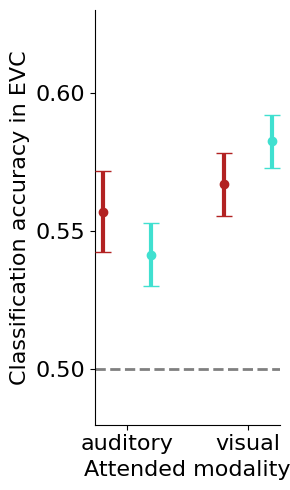

In [7]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [12]:
df["correct"].mean()

np.float64(0.568023097826087)

In [10]:
df.groupby(["modality"])["correct"].mean()

modality
auditory    0.549312
visual      0.574721
Name: correct, dtype: float64

In [11]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,1.613959e-02,1,24,1.613959e-02,3.725103,0.065501,0.065501,2.005266e-02,1.0
1,v_pred,8.506944e-08,1,24,8.506944e-08,0.000022,0.996300,0.996300,1.078575e-07,1.0
2,modality * v_pred,6.071007e-03,1,24,6.071007e-03,2.557319,0.122868,0.122868,7.638489e-03,1.0


In [12]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.930053,24.0,two-sided,0.065501,NaN,NaN,1.037,-0.306600
1,v_pred,-,0,1,True,True,-0.004685,24.0,two-sided,0.996300,NaN,NaN,0.211,-0.000710
2,modality * v_pred,auditory,0,1,True,True,0.837512,24.0,two-sided,0.410568,0.410568,fdr_bh,0.29,0.171849
3,modality * v_pred,visual,0,1,True,True,-1.251142,24.0,two-sided,0.222942,0.410568,fdr_bh,0.423,-0.166752


### Multimodal analyses

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotti

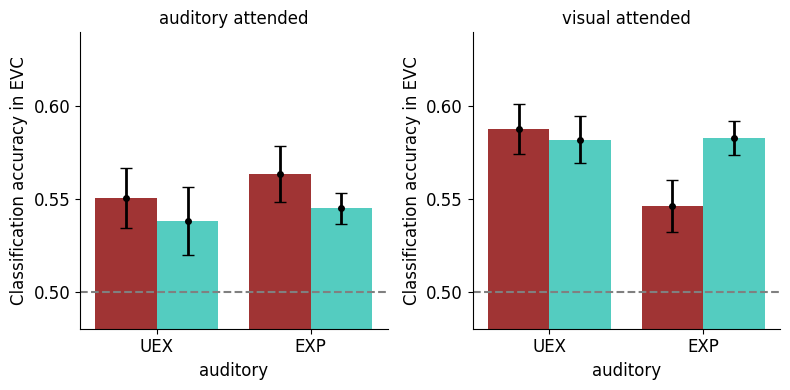

In [8]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)

In [9]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.002446,1,24,0.002446,0.518588,0.478400,0.478400,0.002533,1.0
1,auditory attended,1,v_pred,0.006026,1,24,0.006026,0.701427,0.410568,0.410568,0.006217,1.0
2,auditory attended,2,a_pred * v_pred,0.000249,1,24,0.000249,0.065792,0.799752,0.799752,0.000259,1.0
3,visual attended,0,a_pred,0.010396,1,24,0.010396,2.654435,0.116318,0.116318,0.010223,1.0
4,visual attended,1,v_pred,0.006117,1,24,0.006117,1.565357,0.222942,0.222942,0.006041,1.0
5,visual attended,2,a_pred * v_pred,0.011351,1,24,0.011351,2.895391,0.101755,0.101755,0.011153,1.0


In [26]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,auditory attended,0,a_pred,-,0,1,True,True,-0.423832,23.0,two-sided,0.675626,NaN,NaN,0.233,-0.075410
1,auditory attended,1,v_pred,-,0,1,True,True,0.255974,23.0,two-sided,0.800246,NaN,NaN,0.221,0.042367
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,-0.070689,23.0,two-sided,0.944256,0.944256,fdr_bh,0.215,-0.012772
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,0.450950,23.0,two-sided,0.656248,0.944256,fdr_bh,0.236,0.092214
4,visual attended,0,a_pred,-,0,1,True,True,1.578781,23.0,two-sided,0.128042,NaN,NaN,0.636,0.205114
5,visual attended,1,v_pred,-,0,1,True,True,-1.031290,23.0,two-sided,0.313128,NaN,NaN,0.346,-0.145101
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,0.520853,23.0,two-sided,0.607448,0.607448,fdr_bh,0.243,0.089769
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-1.937597,23.0,two-sided,0.065046,0.130093,fdr_bh,1.059,-0.352750


In [14]:
df_grouped.groupby(["modality", "a_pred", "v_pred"])["correct"].mean().unstack()

v_pred                 0         1
modality a_pred                   
auditory 0       0.55055  0.538183
         1       0.56360  0.544917
visual   0       0.58775  0.582083
         1       0.54605  0.583000

In [12]:
import pingouin as pg
import pandas as pd

results = []

for a in df_grouped['a_pred'].unique():
    for m in df_grouped['modality'].unique():
        subset = df_grouped[(df_grouped['a_pred'] == a) & (df_grouped['modality'] == m)]
        res = pg.pairwise_tests(dv=y, within='v_pred', subject=id, data=subset,
                                padjust='fdr_bh', effsize='cohen')
        res['a_pred'] = a
        res['modality'] = m
        results.append(res)

simple_effects_df = pd.concat(results, ignore_index=True)


In [14]:
from statsmodels.stats.multitest import multipletests

# Extract p-values from your combined simple effects dataframe
raw_pvals = simple_effects_df['p-unc']

# Apply FDR correction
reject, pvals_corr, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# Add corrected results back into the dataframe
simple_effects_df['p-corr'] = pvals_corr
simple_effects_df['significant'] = reject


In [15]:
simple_effects_df

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen,a_pred,modality,p-corr,significant
0,v_pred,0,1,True,True,0.457677,24.0,two-sided,0.651301,0.232,0.106763,0,auditory,0.767326,False
1,v_pred,0,1,True,True,0.299249,24.0,two-sided,0.767326,0.22,0.050743,0,visual,0.767326,False
2,v_pred,0,1,True,True,1.157871,24.0,two-sided,0.258310,0.384,0.229097,1,auditory,0.516620,False
3,v_pred,0,1,True,True,-2.258579,24.0,two-sided,0.033274,1.773,-0.400871,1,visual,0.133098,False
